In [2]:
# =============================================================================
# tt_coach — folder reorganiser  (single Colab cell)
#
# Mounts Drive, finds the project, and restructures it into
# raw / derived / models / outputs, archiving the v1 LSTM experiment.
#
# Nothing is deleted. Files are MOVED, never copied — fast and reversible.
#
# HOW TO USE
#   1. Run this cell as-is.            EXECUTE = False  -> prints the plan only
#   2. Read the plan.
#   3. Change EXECUTE to True, re-run. -> performs the moves
# =============================================================================

EXECUTE = False          # <-- set to True on the second run
BASE_OVERRIDE = None     # <-- e.g. "/content/drive/MyDrive/tt_coach" if not found

# -----------------------------------------------------------------------------
import shutil, sys
from pathlib import Path

PROJECT = "tt_coach"

# --- mount Drive if needed ----------------------------------------------------
def mount_drive():
    for name in ("MyDrive", "My Drive"):
        if (Path("/content/drive") / name).exists():
            print(f"  Drive already mounted."); return
    try:
        from google.colab import drive
    except ImportError:
        print("  Not in Colab — skipping mount."); return
    print("  Mounting Drive ...")
    drive.mount("/content/drive")
    print("  Mounted.")

def drive_roots():
    roots = [Path("/content/drive") / n for n in ("MyDrive", "My Drive")]
    roots.append(Path("/content/drive/Shareddrives"))
    return [r for r in roots if r.exists()]

# --- locate the project folder ------------------------------------------------
def locate_base():
    if BASE_OVERRIDE:
        p = Path(BASE_OVERRIDE)
        if not p.exists():
            raise FileNotFoundError(f"BASE_OVERRIDE does not exist: {p}")
        print(f"  Using: {p}"); return p
    for root in drive_roots():
        if (root / PROJECT).is_dir():
            print(f"  Found: {root / PROJECT}"); return root / PROJECT
    for root in drive_roots():
        for depth in (1, 2):
            for hit in root.glob("/".join(["*"] * depth) + f"/{PROJECT}"):
                if hit.is_dir():
                    print(f"  Found: {hit}"); return hit
    cwd = Path.cwd().resolve()
    for c in [cwd / PROJECT, cwd, *cwd.parents]:
        if c.is_dir() and c.name == PROJECT:
            print(f"  Found: {c}"); return c
    raise FileNotFoundError(
        f"Could not find '{PROJECT}'. Set BASE_OVERRIDE at the top of this cell.")

def notebooks_dir(base):
    for root in drive_roots():
        if (root / "Colab Notebooks").exists():
            return root / "Colab Notebooks"
    p = base.parent / "Colab Notebooks"
    return p if p.exists() else None

TARGET_DIRS = [
    "raw/videos", "raw/videos/legacy_30fps", "raw/labels_extended",
    "raw/labels_original", "derived/pose", "derived/clips", "derived/meta",
    "models/detector", "models/checkpoints", "outputs/metrics",
    "outputs/figures", "notebooks", "_archive_v1", "_archive_v1/session_json",
    "_archive_v1/features", "_archive_v1/checkpoints",
]

# --- build the move plan ------------------------------------------------------
def build_plan(base):
    data, moves = base / "data", []
    def plan(src, dst):
        if src.exists(): moves.append((src, dst))

    # videos — rename so the filename stem IS the video_id
    for i in range(1, 6):
        plan(data / f"game_{i}_120fps.mp4", base / f"raw/videos/game_{i}.mp4")
        plan(data / f"game_{i}_30fps.mp4",
             base / f"raw/videos/legacy_30fps/game_{i}_30fps.mp4")
    for i in range(1, 8):
        plan(data / f"test_{i}.mp4", base / f"raw/videos/test_{i}.mp4")

    # extended stroke labels (DTU / moamal01)
    for i in range(1, 6):
        plan(data / f"game_{i}.json", base / f"raw/labels_extended/game_{i}.json")
    for i in range(1, 8):
        plan(data / f"test_{i}.json", base / f"raw/labels_extended/test_{i}.json")
    for i in range(1, 6):
        plan(data / f"train_game_{i}.json", base / f"_archive_v1/train_game_{i}.json")

    # original OpenTTGames markup folders
    for i in range(1, 8):
        plan(data / f"test_{i}", base / f"raw/labels_original/test_{i}")

    # v1 experiment artefacts
    for i in range(1, 6):
        plan(data / f"session_game_{i}.json",
             base / f"_archive_v1/session_json/session_game_{i}.json")
    plan(data / "features_v4.npz", base / "_archive_v1/features_v4.npz")
    for folder, dest in [("features", "_archive_v1/features"),
                         ("checkpoints", "_archive_v1/checkpoints")]:
        if (base / folder).is_dir():
            for f in (base / folder).iterdir():
                plan(f, base / dest / f.name)

    # detector weights
    det = base / "custom-models/TablePlayerDetector"
    if det.is_dir():
        for f in det.iterdir():
            plan(f, base / f"models/detector/{f.name}")

    # notebooks
    nb = notebooks_dir(base)
    if nb:
        for f in nb.glob("TT*"):
            plan(f, base / f"notebooks/{f.name}")
    return moves

# --- run ----------------------------------------------------------------------
def show_tree(root, prefix="", depth=0, max_depth=2):
    if depth > max_depth or not root.exists(): return
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name))
    for i, p in enumerate(entries):
        last = i == len(entries) - 1
        conn = "`-- " if last else "|-- "
        if p.is_dir():
            n = sum(1 for f in p.rglob("*") if f.is_file())
            print(f"{prefix}{conn}{p.name}/  ({n} files)")
            show_tree(p, prefix + ("    " if last else "|   "), depth + 1, max_depth)
        elif depth <= 1:
            print(f"{prefix}{conn}{p.name}  ({p.stat().st_size/1e6:.1f} MB)")

print("Setup\n" + "-" * 74)
mount_drive()
base = locate_base()
moves = build_plan(base)

print(f"\n{'EXECUTING' if EXECUTE else 'DRY RUN — nothing will change'}\n" + "=" * 74)
if not moves:
    print("  Nothing to move — already organised, or paths differ.")
else:
    if EXECUTE:
        for d in TARGET_DIRS:
            (base / d).mkdir(parents=True, exist_ok=True)
    done = skipped = 0
    for src, dst in moves:
        rel_dst = dst.relative_to(base)
        try:    rel_src = src.relative_to(base)
        except ValueError: rel_src = src
        if dst.exists():
            print(f"  SKIP (exists)   {rel_dst}"); skipped += 1; continue
        print(f"  {rel_src}\n      -> {rel_dst}")
        if EXECUTE:
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(src), str(dst))
        done += 1
    print("=" * 74)
    print(f"  {done} move(s) {'completed' if EXECUTE else 'planned'}, {skipped} skipped")

    if EXECUTE:
        for old in ["data", "features", "checkpoints",
                    "custom-models/TablePlayerDetector", "custom-models"]:
            p = base / old
            if p.is_dir() and not any(p.iterdir()):
                p.rmdir(); print(f"  removed empty dir: {old}")

if EXECUTE:
    print(f"\nStructure of {base}:\n")
    show_tree(base)
else:
    print("\nSet EXECUTE = True at the top of this cell and re-run to apply.")

Setup
--------------------------------------------------------------------------
  Mounting Drive ...
Mounted at /content/drive
  Mounted.
  Found: /content/drive/MyDrive/tt_coach

DRY RUN — nothing will change
  /content/drive/MyDrive/Colab Notebooks/TT-Preflight-Stage.ipynb
      -> notebooks/TT-Preflight-Stage.ipynb
  1 move(s) planned, 0 skipped

Set EXECUTE = True at the top of this cell and re-run to apply.


In [2]:
# =============================================================================
# STEP 1 — LABEL AUDIT                      (Drive must already be mounted)
#
# Parses all 12 extended label files, reports the raw vocabulary, reconciles
# stroke counts against the paper, and applies TAXONOMY.yaml to show the
# 4-class distribution per video.
#
# Touches no video files — runs in seconds.
#
# Writes:  derived/meta/label_audit.csv
#          derived/meta/strokes_raw.csv
# =============================================================================

BASE = "/content/drive/MyDrive/tt_coach"

import json, re, sys
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import yaml

BASE = Path(BASE)
LABELS = BASE / "raw/labels_extended"
META = BASE / "derived/meta"
META.mkdir(parents=True, exist_ok=True)

VIDEOS = [f"game_{i}" for i in range(1, 6)] + [f"test_{i}" for i in range(1, 8)]

# Counts from the paper (arXiv 2512.19327, Tables 2 & 3) for reconciliation
PAPER_TOTALS = {"loop": 583, "serve": 290, "push": 279, "block": 187,
                "flick": 65, "chop": 31, "smash": 12, "lob": 10}
PAPER_STROKE_TOTAL = 1457

# --- load taxonomy ------------------------------------------------------------
tax_path = BASE / "TAXONOMY.yaml"
if not tax_path.exists():
    sys.exit(f"TAXONOMY.yaml not found at {tax_path}")
TAX = yaml.safe_load(tax_path.read_text())

TECH2CLASS = {}
for cls, spec in TAX["classes"].items():
    for tech in spec["techniques"]:
        TECH2CLASS[tech] = cls
print(f"Taxonomy v{TAX.get('version')}: "
      + ", ".join(f"{c}({len(s['techniques'])})" for c, s in TAX["classes"].items()))

SIDES = set(TAX["label_format"]["side_values"])
HIGHS = set(TAX["label_format"]["high_level_values"])
TECHS = set(TAX["label_format"]["technique_values"])

STROKE_RE = re.compile(
    rf"^({'|'.join(SIDES)})_({'|'.join(HIGHS)})_({'|'.join(TECHS)})$")

# --- parse every file ---------------------------------------------------------
rows = []                       # one row per stroke
vocab = Counter()               # every distinct primary token
nonstroke = Counter()           # primary tokens that are not strokes
per_video_total = {}
missing = []
malformed = defaultdict(list)

for vid in VIDEOS:
    p = LABELS / f"{vid}.json"
    if not p.exists():
        missing.append(vid)
        continue

    data = json.loads(p.read_text())
    per_video_total[vid] = len(data)

    for frame_str, raw in data.items():
        parts = str(raw).strip().split()
        if not parts:
            continue
        primary = parts[0]
        vocab[primary] += 1

        m = STROKE_RE.match(primary)
        if not m:
            nonstroke[primary] += 1
            continue

        side, high, tech = m.groups()
        try:
            frame = int(frame_str)
        except ValueError:
            malformed[vid].append(frame_str)
            continue

        rows.append({
            "video_id":   vid,
            "split":      "train" if vid.startswith("game") else "test",
            "frame_120":  frame,
            "side":       side,
            "high_level": high,
            "technique":  tech,
            "shot_class": TECH2CLASS.get(tech),
            "lean":       parts[1] if len(parts) > 1 else None,
            "feet":       parts[2] if len(parts) > 2 else None,
            "raw":        str(raw).strip(),
        })

df = pd.DataFrame(rows)

# =============================================================================
print("\n" + "=" * 78)
print("FILE PRESENCE")
print("=" * 78)
if missing:
    print(f"  !! MISSING label files: {missing}")
else:
    print(f"  All {len(VIDEOS)} label files present.")
print(f"  Total JSON entries across all files: {sum(per_video_total.values())}")

print("\n" + "=" * 78)
print("RAW VOCABULARY  (every distinct first token)")
print("=" * 78)
for tok, n in vocab.most_common():
    kind = "stroke" if STROKE_RE.match(tok) else "other"
    print(f"  {n:5d}  [{kind}]  {tok}")

if nonstroke:
    print("\n  Non-stroke tokens present — these are the merged event/rally layer:")
    print("   ", ", ".join(sorted(nonstroke)))
    if any("empty_event" in t for t in nonstroke):
        print("    -> 'empty_event' IS present: original contact timestamps are")
        print("       already merged in. No need to fetch train events_markup.")
    else:
        print("    -> No 'empty_event' token found in the extended files.")

# =============================================================================
print("\n" + "=" * 78)
print("STROKE COUNTS vs PAPER")
print("=" * 78)
got = df["technique"].value_counts().to_dict()
print(f"  {'technique':<10} {'found':>7} {'paper':>7} {'delta':>7}")
ok = True
for tech in sorted(PAPER_TOTALS, key=lambda t: -PAPER_TOTALS[t]):
    g, e = got.get(tech, 0), PAPER_TOTALS[tech]
    flag = "" if g == e else "   <-- MISMATCH"
    if g != e:
        ok = False
    print(f"  {tech:<10} {g:>7} {e:>7} {g-e:>+7}{flag}")
print(f"  {'TOTAL':<10} {len(df):>7} {PAPER_STROKE_TOTAL:>7} "
      f"{len(df)-PAPER_STROKE_TOTAL:>+7}")
print(f"\n  {'Reconciles with the paper.' if ok and len(df)==PAPER_STROKE_TOTAL else 'Does NOT reconcile — investigate before Stage 0.'}")

# =============================================================================
print("\n" + "=" * 78)
print("4-CLASS DISTRIBUTION  (TAXONOMY.yaml applied)")
print("=" * 78)
cls_counts = df["shot_class"].value_counts()
total = len(df)
for cls in TAX["classes"]:
    n = int(cls_counts.get(cls, 0))
    bar = "#" * int(60 * n / max(cls_counts.max(), 1))
    print(f"  {cls:<10} {n:>5}  ({100*n/total:>4.1f}%)  {bar}")
unmapped = df["shot_class"].isna().sum()
if unmapped:
    print(f"  !! {unmapped} strokes have no class mapping:")
    print("    ", df[df['shot_class'].isna()]['technique'].value_counts().to_dict())
print(f"\n  Imbalance ratio (max:min) = "
      f"{cls_counts.max()/cls_counts.min():.1f}:1")

# =============================================================================
print("\n" + "=" * 78)
print("PER-VIDEO BREAKDOWN  (LOVO fold sizes)")
print("=" * 78)
pv = pd.crosstab(df["video_id"], df["shot_class"])
pv = pv.reindex(index=[v for v in VIDEOS if v in pv.index],
                columns=[c for c in TAX["classes"] if c in pv.columns],
                fill_value=0)
pv["TOTAL"] = pv.sum(axis=1)
print(pv.to_string())
thin = pv[pv["TOTAL"] < 40]
if len(thin):
    print(f"\n  Folds with <40 strokes (noisy, weight by support): "
          f"{list(thin.index)}")
zero = [(v, c) for v in pv.index for c in pv.columns[:-1] if pv.loc[v, c] == 0]
if zero:
    print(f"  Video/class pairs with ZERO examples: {len(zero)}")
    print(f"    e.g. {zero[:6]}")

# =============================================================================
print("\n" + "=" * 78)
print("AUXILIARY LABEL COVERAGE")
print("=" * 78)
for col in ["lean", "feet"]:
    present = df[col].notna().sum()
    print(f"  {col:<6} present on {present}/{len(df)} strokes "
          f"({100*present/len(df):.1f}%)")
    print(f"         values: {dict(df[col].value_counts().head(8))}")

print(f"\n  forehand/backhand: {dict(df['high_level'].value_counts())}")
print(f"  side (L/R):        {dict(df['side'].value_counts())}")

# =============================================================================
if malformed:
    print("\n  !! Non-integer frame keys found:",
          {k: v[:3] for k, v in malformed.items()})

# --- save ---------------------------------------------------------------------
df.sort_values(["video_id", "frame_120"]).to_csv(
    META / "strokes_raw.csv", index=False)
pv.to_csv(META / "label_audit.csv")
print("\n" + "=" * 78)
print(f"  Wrote {META/'strokes_raw.csv'}  ({len(df)} rows)")
print(f"  Wrote {META/'label_audit.csv'}")
print("=" * 78)

Taxonomy v1: serve(1), attack(3), control(1), defence(3)

FILE PRESENCE
  All 12 label files present.
  Total JSON entries across all files: 4945

RAW VOCABULARY  (every distinct first token)
   1757  [other]  bounce
   1330  [other]  net
    167  [stroke]  left_forehand_loop
    147  [stroke]  right_forehand_loop
    135  [stroke]  left_backhand_loop
    134  [stroke]  right_backhand_loop
    119  [other]  empty_event
    113  [stroke]  right_forehand_serve
    100  [stroke]  right_backhand_push
     94  [stroke]  left_backhand_push
     85  [stroke]  left_forehand_serve
     72  [stroke]  right_backhand_block
     71  [other]  left_out
     69  [other]  right_out
     60  [stroke]  left_backhand_block
     59  [stroke]  left_backhand_serve
     45  [stroke]  right_forehand_push
     44  [other]  right_net
     40  [stroke]  left_forehand_push
     39  [other]  left_net
     33  [stroke]  right_backhand_serve
     33  [stroke]  left_backhand_flick
     32  [stroke]  right_forehand_blo

Probing 12 videos ...

  game_1    120.00 fps    738.3s    88599 frames   5.57 GB  1920x1080  h264
  game_2    120.00 fps   1435.0s   172200 frames  10.83 GB  1920x1080  h264
  game_3    120.00 fps    618.0s    74160 frames   4.64 GB  1920x1080  h264
  game_4    120.00 fps    526.0s    63120 frames   3.95 GB  1920x1080  h264
  game_5    120.00 fps   1200.0s   144000 frames   4.49 GB  1920x1080  h264
  test_1    120.00 fps    140.0s    16800 frames   1.05 GB  1920x1080  h264
  test_2    120.00 fps     30.0s     3600 frames   0.23 GB  1920x1080  h264
  test_3    120.00 fps     65.0s     7800 frames   0.49 GB  1920x1080  h264
  test_4    120.00 fps    300.0s    36000 frames   2.25 GB  1920x1080  h264
  test_5    120.00 fps     96.0s    11520 frames   0.72 GB  1920x1080  h264
  test_6    120.00 fps     90.0s    10800 frames   0.68 GB  1920x1080  h264
  test_7    120.00 fps    130.0s    15600 frames   0.49 GB  1920x1080  h264

CONSISTENCY CHECKS
  Distinct frame rates: [np.float64(120.0)]
 

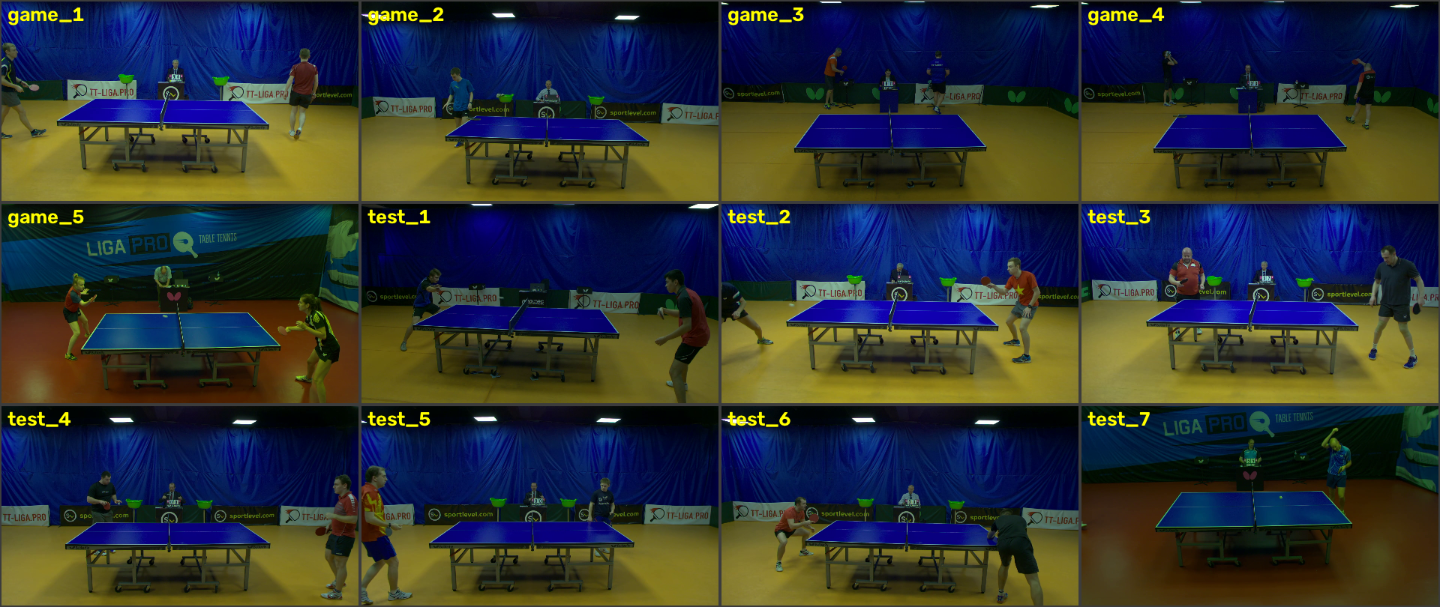

In [3]:
# =============================================================================
# STEP 2 — VIDEO MANIFEST + CAMERA CHECK    (Drive must already be mounted)
#
# Reads headers for all 12 videos (ffprobe), cross-checks that every labelled
# stroke frame falls inside its video, and builds a contact sheet of frame 0
# from each video so you can eyeball whether camera geometry is consistent.
#
# Takes a few minutes — it decodes one frame per video off the Drive mount.
#
# Writes:  derived/meta/video_manifest.csv
#          derived/meta/camera_check.jpg
# =============================================================================

BASE = "/content/drive/MyDrive/tt_coach"

import subprocess, json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

BASE = Path(BASE)
VID_DIR = BASE / "raw/videos"
META = BASE / "derived/meta"
META.mkdir(parents=True, exist_ok=True)

VIDEOS = [f"game_{i}" for i in range(1, 6)] + [f"test_{i}" for i in range(1, 8)]


def ffprobe(path):
    """Return a dict of stream + format info, or None on failure."""
    cmd = ["ffprobe", "-v", "error", "-print_format", "json",
           "-show_format", "-show_streams", "-select_streams", "v:0", str(path)]
    try:
        out = subprocess.run(cmd, capture_output=True, text=True,
                             timeout=180).stdout
        return json.loads(out)
    except Exception as e:
        print(f"    ffprobe failed: {e}")
        return None


def frac(s):
    try:
        n, d = s.split("/")
        return float(n) / float(d) if float(d) else 0.0
    except Exception:
        return 0.0


# --- probe every video --------------------------------------------------------
print("Probing 12 videos ...\n")
rows = []
for vid in VIDEOS:
    p = VID_DIR / f"{vid}.mp4"
    if not p.exists():
        print(f"  {vid:<8} MISSING at {p}")
        rows.append({"video_id": vid, "exists": False})
        continue

    info = ffprobe(p)
    if not info or not info.get("streams"):
        rows.append({"video_id": vid, "exists": True, "probe_ok": False})
        continue

    st, fmt = info["streams"][0], info.get("format", {})
    fps = frac(st.get("r_frame_rate", "0/1"))
    dur = float(fmt.get("duration", 0) or st.get("duration", 0) or 0)
    nbf = int(st.get("nb_frames", 0) or 0)
    size_gb = p.stat().st_size / 1e9

    rows.append({
        "video_id": vid,
        "split": "train" if vid.startswith("game") else "test",
        "exists": True, "probe_ok": True,
        "width": st.get("width"), "height": st.get("height"),
        "fps": round(fps, 3),
        "duration_s": round(dur, 1),
        "nb_frames": nbf if nbf else int(round(dur * fps)),
        "frames_from_duration": int(round(dur * fps)),
        "codec": st.get("codec_name"),
        "size_gb": round(size_gb, 2),
        "gb_per_min": round(size_gb / (dur / 60), 3) if dur else None,
    })
    print(f"  {vid:<8} {fps:>7.2f} fps  {dur:>7.1f}s  "
          f"{rows[-1]['nb_frames']:>7d} frames  {size_gb:>5.2f} GB  "
          f"{st.get('width')}x{st.get('height')}  {st.get('codec_name')}")

mf = pd.DataFrame(rows)

# --- consistency checks -------------------------------------------------------
print("\n" + "=" * 78)
print("CONSISTENCY CHECKS")
print("=" * 78)

good = mf[mf.get("probe_ok", False) == True].copy()

fps_vals = sorted(good["fps"].unique())
print(f"  Distinct frame rates: {fps_vals}")
if len(fps_vals) > 1:
    print("    !! Not all videos are the same fps — frame indices will not be")
    print("       comparable across videos without conversion.")

res = good.groupby(["width", "height"]).size().to_dict()
print(f"  Resolutions: {res}")

print(f"\n  Total duration: {good['duration_s'].sum()/60:.1f} min")
print(f"  Total frames:   {int(good['nb_frames'].sum()):,}")
print(f"  Total size:     {good['size_gb'].sum():.1f} GB")

# bitrate outliers — the game_2 question
med = good["gb_per_min"].median()
print(f"\n  Median GB/min: {med:.3f}")
out = good[good["gb_per_min"] > 1.8 * med]
if len(out):
    print("  Encoding outliers (>1.8x median GB/min):")
    for _, r in out.iterrows():
        print(f"    {r.video_id}: {r.gb_per_min:.3f} GB/min  "
              f"({r.size_gb:.2f} GB / {r.duration_s/60:.1f} min) "
              f"codec={r.codec}")
    print("    -> Larger file but normal duration = just a higher-bitrate")
    print("       encode. Harmless. Only worry if duration is also anomalous.")
else:
    print("  No encoding outliers — file sizes track duration.")

# nb_frames vs duration*fps
mismatch = good[(good["nb_frames"] - good["frames_from_duration"]).abs() > 5]
if len(mismatch):
    print(f"\n  !! nb_frames disagrees with duration*fps for: "
          f"{list(mismatch.video_id)}")
    print("     Use nb_frames, and verify by seeking to the last frame.")

# --- stroke frames must fall inside the video ---------------------------------
sp = META / "strokes_raw.csv"
if sp.exists():
    print("\n" + "=" * 78)
    print("STROKE FRAME RANGE vs VIDEO LENGTH")
    print("=" * 78)
    sdf = pd.read_csv(sp)
    prob = 0
    for _, r in good.iterrows():
        s = sdf[sdf.video_id == r.video_id]
        if not len(s):
            continue
        lo, hi = int(s.frame_120.min()), int(s.frame_120.max())
        over = hi >= r.nb_frames
        tag = "  <-- OUT OF RANGE" if over else ""
        prob += over
        print(f"  {r.video_id:<8} strokes {lo:>7d}..{hi:<7d}  "
              f"video 0..{r.nb_frames-1:<7d}  "
              f"({100*hi/max(r.nb_frames,1):>5.1f}% in){tag}")
    print(f"\n  {'All stroke frames are in range.' if not prob else f'{prob} video(s) have out-of-range stroke frames — check fps assumptions.'}")
else:
    print(f"\n  (Run STEP 1 first to enable the stroke-range check.)")

# --- contact sheet ------------------------------------------------------------
print("\n" + "=" * 78)
print("CAMERA CONTACT SHEET")
print("=" * 78)
TW, TH = 480, 270
tiles = []
for vid in VIDEOS:
    p = VID_DIR / f"{vid}.mp4"
    tile = np.zeros((TH, TW, 3), np.uint8)
    if p.exists():
        cap = cv2.VideoCapture(str(p))
        cap.set(cv2.CAP_PROP_POS_FRAMES, 300)   # skip any lead-in black frames
        ok, fr = cap.read()
        if not ok:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            ok, fr = cap.read()
        cap.release()
        if ok:
            tile = cv2.resize(fr, (TW, TH))
    cv2.rectangle(tile, (0, 0), (TW - 1, TH - 1), (60, 60, 60), 2)
    cv2.putText(tile, vid, (10, 28), cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (0, 0, 0), 5)
    cv2.putText(tile, vid, (10, 28), cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (0, 255, 255), 2)
    tiles.append(tile)
    print(f"  {vid} captured")

sheet = np.vstack([np.hstack(tiles[i:i + 4]) for i in range(0, 12, 4)])
out_path = META / "camera_check.jpg"
cv2.imwrite(str(out_path), sheet, [cv2.IMWRITE_JPEG_QUALITY, 88])

mf.to_csv(META / "video_manifest.csv", index=False)
print("\n" + "=" * 78)
print(f"  Wrote {META/'video_manifest.csv'}")
print(f"  Wrote {out_path}")
print("=" * 78)
print("\n  Look at the contact sheet: does the table sit in roughly the same")
print("  place in all 12? If yes -> skip homography, use torso-normalised")
print("  bbox distance. If the camera moves a lot between videos -> revisit.\n")

try:
    from google.colab.patches import cv2_imshow
    cv2_imshow(cv2.resize(sheet, (1440, int(1440 * sheet.shape[0] / sheet.shape[1]))))
except ImportError:
    pass

In [1]:
# =============================================================================
# STEP 3 — ENVIRONMENT SETUP + VERIFICATION   (Drive must already be mounted)
#
# Installs and smoke-tests the pose stack before Stage 2 commits GPU hours.
# Run this ONCE per fresh Colab runtime.
#
# Deliberately uses rtmlib (ONNX RTMPose) rather than mmpose — no mmcv
# version hell, pip-installable, and gives RTMPose-L quality out of the box.
# =============================================================================

BASE = "/content/drive/MyDrive/tt_coach"

# --- 1. install ---------------------------------------------------------------
print("Installing ...")
!pip install -q rtmlib onnxruntime-gpu ultralytics lightgbm shap pyarrow 2>&1 | tail -3
print("done.\n")

# --- 2. hardware --------------------------------------------------------------
import torch, cv2, sys, subprocess
from pathlib import Path

print("=" * 78)
print("HARDWARE")
print("=" * 78)
print(f"  Python      : {sys.version.split()[0]}")
print(f"  PyTorch     : {torch.__version__}")
print(f"  CUDA avail  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  !! No GPU. Runtime > Change runtime type > GPU before Stage 2.")
print(f"  OpenCV      : {cv2.__version__}")

try:
    import onnxruntime as ort
    print(f"  onnxruntime : {ort.__version__}")
    print(f"  providers   : {ort.get_available_providers()}")
    if "CUDAExecutionProvider" not in ort.get_available_providers():
        print("    !! CUDA provider missing — RTMPose will run on CPU (very slow).")
except ImportError:
    print("  !! onnxruntime not importable")

# --- 3. rtmlib smoke test -----------------------------------------------------
print("\n" + "=" * 78)
print("RTMPOSE SMOKE TEST")
print("=" * 78)
import numpy as np
try:
    from rtmlib import Wholebody, Body

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    backend = "onnxruntime"
    print(f"  Loading Body (RTMPose) on {dev} — first run downloads weights ...")
    pose = Body(mode="performance", backend=backend, device=dev)

    dummy = np.zeros((1080, 1920, 3), dtype=np.uint8)
    kpts, scores = pose(dummy)
    print(f"  OK. Output shapes: keypoints={np.array(kpts).shape}, "
          f"scores={np.array(scores).shape}")
    print("  (Empty frame -> 0 detections is expected.)")
except Exception as e:
    print(f"  !! rtmlib failed: {type(e).__name__}: {e}")
    print("     Fallback: use ultralytics YOLO pose, but expect lower wrist accuracy.")

# --- 4. detector loads --------------------------------------------------------
print("\n" + "=" * 78)
print("CUSTOM DETECTOR")
print("=" * 78)
det_path = Path(BASE) / "models/detector/best.pt"
if det_path.exists():
    try:
        from ultralytics import YOLO
        det = YOLO(str(det_path))
        print(f"  Loaded {det_path.name}")
        print(f"  Classes: {det.names}")
    except Exception as e:
        print(f"  !! Failed to load: {e}")
else:
    print(f"  !! Not found at {det_path}")

# --- 5. project structure -----------------------------------------------------
print("\n" + "=" * 78)
print("PROJECT STRUCTURE")
print("=" * 78)
BASE = Path(BASE)
expected = [
    "TAXONOMY.yaml", "raw/videos", "raw/labels_extended", "raw/labels_original",
    "derived/pose", "derived/clips", "derived/meta",
    "models/detector", "models/checkpoints",
    "outputs/metrics", "outputs/figures", "notebooks",
]
missing = []
for rel in expected:
    p = BASE / rel
    if p.exists():
        n = sum(1 for f in p.rglob("*") if f.is_file()) if p.is_dir() else 1
        print(f"  OK   {rel:<28} ({n} files)")
    else:
        print(f"  MISS {rel}")
        missing.append(rel)

# --- 6. free space ------------------------------------------------------------
print("\n" + "=" * 78)
print("DISK")
print("=" * 78)
print(subprocess.run(["df", "-h", "/content", str(BASE)],
                     capture_output=True, text=True).stdout)

print("=" * 78)
print("  Environment ready." if not missing
      else f"  Missing paths: {missing}")
print("=" * 78)

Installing ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 60.6 MB/s eta 0:00:00
done.

HARDWARE
  Python      : 3.12.13
  PyTorch     : 2.11.0+cu128
  CUDA avail  : True
  GPU         : Tesla T4
  VRAM        : 15.6 GB
  OpenCV      : 4.13.0
  onnxruntime : 1.28.0
  providers   : ['AzureExecutionProvider', 'CPUExecutionProvider']
    !! CUDA provider missing — RTMPose will run on CPU (very slow).

RTMPOSE SMOKE TEST
  Loading Body (RTMPose) on cuda — first run downloads weights ...


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/yolox_x_8xb8-300e_humanart-a39d44ed.zip" to /root/.cache/rtmlib/hub/checkpoints/yolox_x_8xb8-300e_humanart-a39d44ed.zip
100%|██████████| 351M/351M [00:12<00:00, 30.6MB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.zip


load /root/.cache/rtmlib/hub/checkpoints/yolox_x_8xb8-300e_humanart-a39d44ed.onnx with onnxruntime backend


100%|██████████| 176M/176M [00:07<00:00, 24.2MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.onnx with onnxruntime backend
  OK. Output shapes: keypoints=(1, 17, 2), scores=(1, 17)
  (Empty frame -> 0 detections is expected.)

CUSTOM DETECTOR
  !! Not found at /content/drive/MyDrive/tt_coach/models/detector/best.pt

PROJECT STRUCTURE
  MISS TAXONOMY.yaml
  MISS raw/videos
  MISS raw/labels_extended
  MISS raw/labels_original
  MISS derived/pose
  MISS derived/clips
  MISS derived/meta
  MISS models/detector
  MISS models/checkpoints
  MISS outputs/metrics
  MISS outputs/figures
  MISS notebooks

DISK
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   65G  43% /

  Missing paths: ['TAXONOMY.yaml', 'raw/videos', 'raw/labels_extended', 'raw/labels_original', 'derived/pose', 'derived/clips', 'derived/meta', 'models/detector', 'models/checkpoints', 'outputs/metrics', 'outputs/figures', 'notebooks']


In [4]:
# =============================================================================
# STEP 3a — PACKAGE FIX          (run FIRST on a fresh runtime, then RESTART)
#
# Colab preinstalls onnxruntime (CPU). Installing onnxruntime-gpu alongside it
# does NOT work — both packages share the `onnxruntime` module namespace and
# the CPU build shadows the GPU one, so CUDAExecutionProvider never appears.
#
# Both must be removed, then only the GPU wheel installed, then the runtime
# restarted (the module is already loaded in memory otherwise).
#
# AFTER THIS CELL:  Runtime > Restart session   then run the mount cell,
#                   then STEP 3b.
# =============================================================================

import torch
assert torch.cuda.is_available(), (
    "No GPU. Runtime > Change runtime type > T4 GPU, then re-run this cell.")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- 1. remove BOTH onnxruntime builds ---------------------------------------
print("\nRemoving conflicting onnxruntime packages ...")
!pip uninstall -y -q onnxruntime onnxruntime-gpu onnxruntime-openvino 2>&1 | tail -2

# --- 2. install only the GPU wheel -------------------------------------------
# 1.22.x is the last line reliably matching Colab's CUDA 12 + cuDNN 9 stack.
print("\nInstalling onnxruntime-gpu ...")
!pip install -q "onnxruntime-gpu>=1.22,<1.23" 2>&1 | tail -3

# --- 3. everything else -------------------------------------------------------
print("\nInstalling remaining packages ...")
!pip install -q rtmlib ultralytics lightgbm shap pyarrow 2>&1 | tail -3

# --- 4. confirm exactly one onnxruntime is present ---------------------------
print("\nInstalled onnxruntime packages:")
!pip list 2>/dev/null | grep -i onnxruntime

print("\n" + "=" * 74)
print("  NOW: Runtime > Restart session")
print("  Then run the drive.mount cell, then STEP 3b.")
print("  (Do NOT skip the restart — the CPU module is still loaded in memory.)")
print("=" * 74)

GPU: Tesla T4

Removing conflicting onnxruntime packages ...

Installing onnxruntime-gpu ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.9 MB/s eta 0:00:00

Installing remaining packages ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 93.1 MB/s eta 0:00:00

Installed onnxruntime packages:
onnxruntime                           1.28.0
onnxruntime-gpu                       1.22.0

  NOW: Runtime > Restart session
  Then run the drive.mount cell, then STEP 3b.
  (Do NOT skip the restart — the CPU module is still loaded in memory.)


In [3]:
# =============================================================================
# STEP 3b — VERIFY          (run AFTER restart AND after drive.mount)
#
# Confirms the GPU pose stack is actually using CUDA, benchmarks it so you can
# project Stage 2 cost, loads the detector, and checks the project tree.
# =============================================================================

BASE = "/content/drive/MyDrive/tt_coach"

import sys, time, subprocess
from pathlib import Path
import numpy as np

# --- 0. Drive must be mounted -------------------------------------------------
if not Path("/content/drive/MyDrive").exists():
    raise RuntimeError(
        "Drive is not mounted. Run this in a cell above, then re-run:\n\n"
        "    from google.colab import drive\n"
        "    drive.mount('/content/drive')")
print("Drive mounted.\n")

# --- 1. hardware --------------------------------------------------------------
import torch, cv2
print("=" * 78)
print("HARDWARE")
print("=" * 78)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  PyTorch    : {torch.__version__}")
print(f"  CUDA       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU        : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  OpenCV     : {cv2.__version__}")

# --- 2. the decisive check ----------------------------------------------------
print("\n" + "=" * 78)
print("ONNXRUNTIME PROVIDERS  (the thing that was broken)")
print("=" * 78)
import onnxruntime as ort
provs = ort.get_available_providers()
print(f"  onnxruntime : {ort.__version__}")
print(f"  providers   : {provs}")

ORT_CUDA = "CUDAExecutionProvider" in provs
if ORT_CUDA:
    print("\n  CUDAExecutionProvider present — RTMPose will run on GPU.")
else:
    print("\n  !! CUDAExecutionProvider STILL missing.")
    print("     Checklist:")
    print("       1. Did you restart the session after STEP 3a?")
    print("       2. `pip list | grep onnxruntime` should show ONLY")
    print("          onnxruntime-gpu, never plain onnxruntime.")
    print("     If both are still listed, re-run STEP 3a and restart again.")
    print("     If it persists, PLAN B below runs pose on GPU via PyTorch.")

# --- 3. benchmark whichever backend works ------------------------------------
print("\n" + "=" * 78)
print("POSE BACKEND BENCHMARK")
print("=" * 78)

# Synthetic 1080p frame with a person-ish blob so detection has something to do
frame = np.full((1080, 1920, 3), 40, np.uint8)
cv2.rectangle(frame, (820, 300), (1000, 850), (150, 140, 130), -1)
cv2.circle(frame, (910, 260), 55, (170, 160, 150), -1)

BACKEND = None
if ORT_CUDA:
    try:
        from rtmlib import Body
        print("  Loading rtmlib Body (RTMPose, ONNX/CUDA) ...")
        pose = Body(mode="performance", backend="onnxruntime", device="cuda")
        for _ in range(3):                      # warm up
            pose(frame)
        t0 = time.time()
        N = 15
        for _ in range(N):
            kpts, scores = pose(frame)
        dt = (time.time() - t0) / N
        print(f"  OK — {dt*1000:.0f} ms/frame  ({1/dt:.1f} fps)")
        print(f"  keypoints={np.array(kpts).shape}  scores={np.array(scores).shape}")
        BACKEND = "rtmlib-cuda"
    except Exception as e:
        print(f"  !! rtmlib/CUDA failed: {type(e).__name__}: {e}")

if BACKEND is None:
    print("\n  PLAN B — ultralytics YOLO11 pose (PyTorch, GPU). Slightly lower")
    print("  wrist accuracy than RTMPose-x but no ONNX dependency at all.")
    try:
        from ultralytics import YOLO
        yp = YOLO("yolo11x-pose.pt")
        yp.to("cuda")
        for _ in range(2):
            yp.predict(frame, verbose=False)
        t0 = time.time()
        N = 15
        for _ in range(N):
            r = yp.predict(frame, verbose=False)
        dt = (time.time() - t0) / N
        print(f"  OK — {dt*1000:.0f} ms/frame  ({1/dt:.1f} fps)")
        BACKEND = "yolo11x-pose-cuda"
    except Exception as e:
        print(f"  !! Plan B also failed: {type(e).__name__}: {e}")

# --- 4. project Stage 2 cost --------------------------------------------------
if BACKEND:
    print("\n" + "=" * 78)
    print("STAGE 2 COST PROJECTION")
    print("=" * 78)
    STROKES, WINDOW, PLAYERS = 1456, 96, 2
    ALL_FRAMES = 644_199
    windowed = STROKES * WINDOW * PLAYERS
    print(f"  Backend: {BACKEND}   ({dt*1000:.0f} ms/frame)")
    print(f"  Windowed  ({STROKES} strokes x {WINDOW}f x {PLAYERS}p) "
          f"= {windowed:,} inferences -> {windowed*dt/3600:>5.1f} h")
    print(f"  Full video ({ALL_FRAMES:,}f x {PLAYERS}p) "
          f"= {ALL_FRAMES*PLAYERS:,} inferences -> {ALL_FRAMES*PLAYERS*dt/3600:>5.1f} h")
    print("\n  Windowed extraction covers Stages 3-5. Only Stage 6 (contact")
    print("  detection) needs continuous pose, and only on a subset.")

# --- 5. detector --------------------------------------------------------------
print("\n" + "=" * 78)
print("CUSTOM DETECTOR")
print("=" * 78)
det_path = Path(BASE) / "models/detector/best.pt"
if det_path.exists():
    try:
        from ultralytics import YOLO
        det = YOLO(str(det_path))
        det.to("cuda")
        print(f"  Loaded {det_path.name} -> classes {det.names}")
    except Exception as e:
        print(f"  !! Load failed: {e}")
else:
    print(f"  !! Not found: {det_path}")

# --- 6. structure -------------------------------------------------------------
print("\n" + "=" * 78)
print("PROJECT STRUCTURE")
print("=" * 78)
BASE = Path(BASE)
expected = ["TAXONOMY.yaml", "raw/videos", "raw/labels_extended",
            "raw/labels_original", "derived/pose", "derived/clips",
            "derived/meta", "models/detector", "models/checkpoints",
            "outputs/metrics", "outputs/figures", "notebooks"]
missing = []
for rel in expected:
    p = BASE / rel
    if p.exists():
        n = sum(1 for f in p.rglob("*") if f.is_file()) if p.is_dir() else 1
        print(f"  OK   {rel:<28} ({n} files)")
    else:
        print(f"  MISS {rel}")
        missing.append(rel)

for f in ["strokes_raw.csv", "video_manifest.csv", "camera_check.jpg"]:
    p = BASE / "derived/meta" / f
    print(f"  {'OK  ' if p.exists() else 'MISS'} derived/meta/{f}")

print("\n" + "=" * 78)
ready = bool(BACKEND) and not missing and det_path.exists()
print(f"  {'READY for Stage 0.' if ready else 'Not ready — see items above.'}")
print(f"  Pose backend: {BACKEND or 'NONE'}")
print("=" * 78)

Drive mounted.

HARDWARE
  Python     : 3.12.13
  PyTorch    : 2.11.0+cu128
  CUDA       : True
  GPU        : Tesla T4
  VRAM       : 15.6 GB
  OpenCV     : 4.13.0

ONNXRUNTIME PROVIDERS  (the thing that was broken)


ModuleNotFoundError: No module named 'onnxruntime'

In [4]:
# =============================================================================
# STEP 3a-v2 — ONNXRUNTIME GPU FIX        (run on a fresh runtime, then RESTART)
#
# Why v1 failed: rtmlib declares `onnxruntime` (CPU) as a dependency, so
# installing rtmlib AFTER onnxruntime-gpu silently reinstalls the CPU build
# over it. Both live in the same `onnxruntime` module namespace and CPU wins.
#
# Fix: install rtmlib with --no-deps, and put onnxruntime-gpu LAST.
#
# AFTER THIS CELL:  Runtime > Restart session  ->  drive.mount  ->  STEP 3b
# =============================================================================

import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4."
print(f"GPU: {torch.cuda.get_device_name(0)}   torch {torch.__version__}\n")

print("--- what's installed right now ---")
!pip list 2>/dev/null | grep -iE "onnxruntime|rtmlib"

# --- 1. purge every onnxruntime build ----------------------------------------
print("\n--- purging onnxruntime ---")
!pip uninstall -y onnxruntime onnxruntime-gpu onnxruntime-openvino onnxruntime-silicon 2>&1 | grep -iE "success|not installed" | head

# --- 2. rtmlib WITHOUT its deps (this is the fix) ----------------------------
print("\n--- rtmlib (--no-deps, so it can't drag CPU onnxruntime back) ---")
!pip install -q --no-deps rtmlib 2>&1 | tail -2
# rtmlib's real runtime needs, minus onnxruntime
!pip install -q opencv-python numpy tqdm 2>&1 | tail -2

# --- 3. other project packages BEFORE onnxruntime-gpu ------------------------
print("\n--- project packages ---")
!pip install -q ultralytics lightgbm shap pyarrow 2>&1 | tail -2

# --- 4. onnxruntime-gpu LAST so nothing can override it ----------------------
print("\n--- onnxruntime-gpu (last) ---")
!pip install -q "onnxruntime-gpu==1.22.0" 2>&1 | tail -3

# --- 5. verify exactly one build remains -------------------------------------
print("\n--- final state (must show ONLY onnxruntime-gpu) ---")
!pip list 2>/dev/null | grep -iE "onnxruntime|rtmlib"

# --- 6. expose torch's bundled CUDA/cuDNN libs to onnxruntime ----------------
# onnxruntime-gpu looks for libcudnn/libcublas on the loader path. torch ships
# its own copies under site-packages/nvidia/*; pointing there avoids having to
# install a system CUDA toolkit.
import os, glob, site
libs = []
for sp in site.getsitepackages():
    libs += glob.glob(os.path.join(sp, "nvidia", "*", "lib"))
if libs:
    os.environ["LD_LIBRARY_PATH"] = ":".join(libs + [os.environ.get("LD_LIBRARY_PATH", "")])
    print(f"\n  Added {len(libs)} nvidia lib dirs to LD_LIBRARY_PATH")
    with open("/content/_ort_libpath.txt", "w") as f:
        f.write(":".join(libs))
    print("  Saved to /content/_ort_libpath.txt (STEP 3b re-applies it)")

print("\n" + "=" * 74)
print("  NOW: Runtime > Restart session")
print("  Then: drive.mount cell  ->  STEP 3b")
print("=" * 74)

GPU: Tesla T4   torch 2.11.0+cu128

--- what's installed right now ---

--- purging onnxruntime ---

--- rtmlib (--no-deps, so it can't drag CPU onnxruntime back) ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.5 MB/s eta 0:00:00

--- project packages ---
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.5 MB/s eta 0:00:00

--- onnxruntime-gpu (last) ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.4 MB/s eta 0:00:00

--- final state (must show ONLY onnxruntime-gpu) ---
onnxruntime-gpu                       1.22.0
rtmlib                                0.0.16

  Added 17 nvidia lib dirs to LD_LIBRARY_PATH
  Saved to /content/_ort_libpath.txt (STEP 3b re-applies it)

  NOW: Runtime > Restart session
  Then: drive.mou

In [5]:
# =============================================================================
# STEP 3c — BATCHED POSE BENCHMARK        (after restart + drive.mount)
#
# The 40 ms/frame from STEP 3b was SINGLE-IMAGE, FULL-FRAME inference. Neither
# matches how Stage 2 will actually run:
#   - frames come in batches, and a T4 is badly underused at batch=1
#   - you already have a player detector, so pose runs on crops, not on 1080p
#   - fp16 roughly doubles throughput on a T4
#
# This measures the real number so the Stage 2 estimate is honest, and compares
# model sizes so you can trade accuracy against hours deliberately.
# =============================================================================

import os, time, glob, site
from pathlib import Path
import numpy as np

# re-apply the CUDA lib path saved by STEP 3a-v2
p = Path("/content/_ort_libpath.txt")
if p.exists():
    os.environ["LD_LIBRARY_PATH"] = p.read_text() + ":" + os.environ.get("LD_LIBRARY_PATH", "")

import torch, cv2
assert torch.cuda.is_available(), "No GPU."
print(f"GPU: {torch.cuda.get_device_name(0)}\n")

STROKES, WINDOW, PLAYERS = 1456, 96, 2
WINDOWED = STROKES * WINDOW * PLAYERS          # 279,552
FULL = 644_199 * PLAYERS                       # 1,288,398


def synth_frame(h=1080, w=1920):
    f = np.full((h, w, 3), 40, np.uint8)
    for cx in (500, 1450):
        cv2.rectangle(f, (cx - 70, 380), (cx + 70, 880), (150, 140, 130), -1)
        cv2.circle(f, (cx, 340), 50, (170, 160, 150), -1)
    return f


def synth_crop(s=384):
    c = np.full((s, s, 3), 45, np.uint8)
    cv2.rectangle(c, (s//3, s//6), (2*s//3, 5*s//6), (150, 140, 130), -1)
    cv2.circle(c, (s//2, s//8), s//12, (170, 160, 150), -1)
    return c


frame = synth_frame()
crop = synth_crop()
results = {}


def report(name, dt):
    results[name] = dt
    print(f"  {name:<34} {dt*1000:>7.1f} ms/inf   "
          f"windowed {WINDOWED*dt/3600:>5.2f} h   full {FULL*dt/3600:>5.1f} h")


# --- A. ONNX RTMPose on crops (best case, if CUDA provider is available) -----
print("=" * 90)
print("A. RTMPose via onnxruntime")
print("=" * 90)
try:
    import onnxruntime as ort
    provs = ort.get_available_providers()
    print(f"  onnxruntime {ort.__version__}  providers={provs}")
    if "CUDAExecutionProvider" in provs:
        from rtmlib import RTMPose
        # RTMPose alone, fed our own boxes — skips rtmlib's 351 MB YOLOX
        rp = RTMPose(
            onnx_model="https://download.openmmlab.com/mmpose/v1/projects/"
                       "rtmposev1/onnx_sdk/rtmpose-l_simcc-body7_pt-body7_"
                       "420e-384x288-3f5a1437_20230504.zip",
            model_input_size=(288, 384), backend="onnxruntime", device="cuda")
        boxes = [[430, 330, 570, 890], [1380, 330, 1520, 890]]
        for _ in range(3):
            rp(frame, bboxes=boxes)
        t0 = time.time(); N = 20
        for _ in range(N):
            rp(frame, bboxes=boxes)
        report("RTMPose-l  ONNX/CUDA  (2 crops)", (time.time() - t0) / (N * 2))
    else:
        print("  CUDAExecutionProvider absent — skipping. Run STEP 3a-v2.")
except Exception as e:
    print(f"  failed: {type(e).__name__}: {e}")

# --- B. ultralytics pose, batched, fp16, several sizes -----------------------
print("\n" + "=" * 90)
print("B. ultralytics YOLO11 pose — batched, fp16, full 1080p frame")
print("=" * 90)
from ultralytics import YOLO

for size in ["yolo11m-pose.pt", "yolo11l-pose.pt", "yolo11x-pose.pt"]:
    try:
        m = YOLO(size); m.to("cuda")
        for B in [1, 8, 16]:
            batch = [frame] * B
            for _ in range(2):
                m.predict(batch, verbose=False, half=True, imgsz=1280)
            torch.cuda.synchronize()
            t0 = time.time(); N = 5
            for _ in range(N):
                m.predict(batch, verbose=False, half=True, imgsz=1280)
            torch.cuda.synchronize()
            dt = (time.time() - t0) / (N * B)
            report(f"{size[:-3]:<16} fp16 b={B:<3}", dt)
        del m; torch.cuda.empty_cache()
    except Exception as e:
        print(f"  {size} failed: {type(e).__name__}: {e}")

# --- summary ------------------------------------------------------------------
print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)
if results:
    best = min(results, key=results.get)
    bd = results[best]
    print(f"  Fastest: {best}  ({bd*1000:.1f} ms/inf)")
    print(f"  Stage 2 windowed extraction: {WINDOWED*bd/3600:.2f} h")
    print(f"  Full continuous extraction : {FULL*bd/3600:.1f} h")
    print("\n  Guidance:")
    print("   - Windowed under ~2 h -> comfortable in one Colab session.")
    print("   - Over ~4 h -> checkpoint per video and expect 2 sessions.")
    print("   - Prefer the largest model whose windowed time you can afford;")
    print("     wrist keypoint quality is the main driver of attack-vs-control.")
else:
    print("  No backend completed.")

GPU: Tesla T4

A. RTMPose via onnxruntime
  onnxruntime 1.22.0  providers=['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip
100%|██████████| 98.9M/98.9M [00:04<00:00, 25.7MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.onnx with onnxruntime backend
  RTMPose-l  ONNX/CUDA  (2 crops)       16.0 ms/inf   windowed  1.24 h   full   5.7 h

B. ultralytics YOLO11 pose — batched, fp16, full 1080p frame
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be 